In [1]:
from pathlib import Path
import numpy as np
import time
from typing import List, Dict, Tuple
import dimod
import neal
import matplotlib.pyplot as plt

In [2]:
# Problem data
v = [92, 57, 49, 68, 60, 43, 67, 84, 87, 72]
w = [23, 31, 29, 44, 53, 38, 63, 85, 89, 82]
C = 165
N = len(v)

print("✓ Notebook data set up")
print(f"Items: {N}")
print(f"Capacity: {C}")
print(f"Values: {v}")
print(f"Weights: {w}")

✓ Notebook data set up
Items: 10
Capacity: 165
Values: [92, 57, 49, 68, 60, 43, 67, 84, 87, 72]
Weights: [23, 31, 29, 44, 53, 38, 63, 85, 89, 82]


In [3]:
# Set random seed for reproducibility
seed = 11202038  # Replace with your student ID
np.random.seed(seed)

print(f"Random seed: {seed}")
print()

Random seed: 11202038



In [4]:
# Dynamic programming
t0 = time.time()

# dp[i][c] = max value using first i items with capacity c
dp = [[0 for _ in range(C + 1)] for _ in range(N + 1)]

for i in range(1, N + 1):
    for c in range(C + 1):
        dp[i][c] = dp[i - 1][c]
        if w[i - 1] <= c:
            cand = dp[i - 1][c - w[i - 1]] + v[i - 1]
            if cand > dp[i][c]:
                dp[i][c] = cand

# Backtrack selected items
sel_c = []
c = C
for i in range(N, 0, -1):
    if dp[i][c] != dp[i - 1][c]:
        sel_c.append(i - 1)
        c -= w[i - 1]
sel_c.reverse()
wt_c = sum(w[i] for i in sel_c)
val_c = sum(v[i] for i in sel_c)

t_c = time.time() - t0

print(f"Selected items (0-indexed): {sel_c}")
print(f"Selected items (1-indexed): {[i + 1 for i in sel_c]}")
print(f"Total weight: {wt_c}")
print(f"Total value: {val_c}")
print(f"Feasible: {wt_c <= C}")
print(f"Time: {t_c:.6f} seconds")
print()

classical_result = {
    'selected': sel_c,
    'weight': wt_c,
    'value': val_c,
    'time': t_c
}

Selected items (0-indexed): [0, 1, 2, 3, 5]
Selected items (1-indexed): [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Time: 0.001571 seconds



## Part 2: QUBO Formulation and Exact Solver

In [5]:
# Build Q and M for a given lambda

def build_q(lam):
    M = int(np.ceil(np.log2(C)))
    Q = {}

    for i in range(N):
        Q[(i, i)] = Q.get((i, i), 0) - v[i]

    for i in range(N):
        for j in range(i + 1, N):
            Q[(i, j)] = Q.get((i, j), 0) + lam * 2 * w[i] * w[j]

    for i in range(N):
        Q[(i, i)] = Q.get((i, i), 0) + lam * w[i] ** 2 - lam * 2 * w[i] * C

    for k in range(M):
        for l in range(k + 1, M):
            ik = N + k
            il = N + l
            wk = 2 ** k
            wl = 2 ** l
            Q[(ik, il)] = Q.get((ik, il), 0) + lam * 2 * wk * wl

    for k in range(M):
        ik = N + k
        wk = 2 ** k
        Q[(ik, ik)] = Q.get((ik, ik), 0) + lam * wk ** 2 - lam * 2 * wk * C

    for i in range(N):
        for k in range(M):
            ik = N + k
            wk = 2 ** k
            Q[(i, ik)] = Q.get((i, ik), 0) + lam * 2 * w[i] * wk

    return Q, M


lam = 50
Q, M = build_q(lam)

print(f"lambda: {lam}")
print(f"slack bits: {M}")
print(f"total binary vars: {N + M}")
print(f"Q entries: {len(Q)}")

lambda: 50
slack bits: 8
total binary vars: 18
Q entries: 171


In [6]:
print("=" * 80)
print("PART 2: QUBO Formulation with Slack Variables")
print("=" * 80)
print()

lambda_values = [0.001, 0.01, 0.1, 1, 10]
exact_results = {}

for lam in lambda_values:
    Q, M = build_q(lam)
    print(f"lambda = {lam}")
    print(f"slack bits = {M}")
    print(f"total binary variables = {N + M}")
    print(f"QUBO entries = {len(Q)}")

    t0 = time.time()
    bqm = dimod.BQM.from_qubo(Q)
    res = dimod.ExactSolver().sample(bqm)
    t_ex = time.time() - t0

    best = res.first.sample
    sel_ex = [i for i in range(N) if best[i] == 1]
    wt_ex = sum(w[i] for i in sel_ex)
    val_ex = sum(v[i] for i in sel_ex)
    feas_ex = wt_ex <= C
    opt_ex = val_ex == val_c

    print(f"Selected items: {[i + 1 for i in sel_ex]}")
    print(f"Total weight: {wt_ex}")
    print(f"Total value: {val_ex}")
    print(f"Feasible: {feas_ex}")
    print(f"Optimal: {opt_ex}")
    print(f"Best energy: {res.first.energy:.6f}")
    print(f"Time: {t_ex:.6f} seconds")
    print()

    exact_results[lam] = {
        'selected': sel_ex,
        'weight': wt_ex,
        'value': val_ex,
        'feasible': feas_ex,
        'optimal': opt_ex,
        'energy': res.first.energy,
        'time': t_ex,
        'Q': Q,
        'M': M,
    }

best_lam = max([lam for lam in lambda_values if exact_results[lam]['feasible']], default=lambda_values[-1])
Q, M = build_q(best_lam)
exact_result = exact_results[best_lam]

print(f"Using lambda = {best_lam} as the final Q for later cells")

PART 2: QUBO Formulation with Slack Variables

lambda = 0.001
slack bits = 8
total binary variables = 18
QUBO entries = 171
Selected items: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Total weight: 537
Total value: 679
Feasible: False
Optimal: False
Best energy: -567.841000
Time: 0.321630 seconds

lambda = 0.01
slack bits = 8
total binary variables = 18
QUBO entries = 171
Selected items: [1, 2, 3, 4, 5, 6]
Total weight: 218
Total value: 369
Feasible: False
Optimal: False
Best energy: -613.160000
Time: 0.269472 seconds

lambda = 0.1
slack bits = 8
total binary variables = 18
QUBO entries = 171
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Best energy: -3031.500000
Time: 0.266573 seconds

lambda = 1
slack bits = 8
total binary variables = 18
QUBO entries = 171
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Best energy: -27534.000000
Time: 0.276187 seconds

lambda = 10
slack bits = 8
total binary variab

## Part 3: Simulated Annealing

In [7]:
# Use the best lambda from the exact-solver sweep
Q, M = build_q(best_lam)
print(f"Using lambda = {best_lam} for simulated annealing")
print()

num_reads_values = [10, 100, 1000, 10000]
sa_results = {}

Using lambda = 10 for simulated annealing



In [8]:
# Run simulated annealing with different num_reads
opt_bits = [1 if i in sel_c else 0 for i in range(N)]

for num_reads in num_reads_values:
    print(f"num_reads = {num_reads}")
    print("-" * 40)

    t0 = time.time()
    bqm = dimod.BQM.from_qubo(Q)
    res = neal.SimulatedAnnealingSampler().sample(bqm, num_reads=num_reads, seed=seed)
    t_sa = time.time() - t0

    best = res.first.sample
    sel_sa = [i for i in range(N) if best[i] == 1]
    wt_sa = sum(w[i] for i in sel_sa)
    val_sa = sum(v[i] for i in sel_sa)

    hit = 0
    for rec in res.data():
        sb = [rec.sample[i] for i in range(N)]
        if sb == opt_bits:
            hit += 1
    p_succ = hit / num_reads if num_reads > 0 else 0.0

    feas_sa = wt_sa <= C
    opt_sa = val_sa == val_c

    print(f"Selected items: {[i + 1 for i in sel_sa]}")
    print(f"Total weight: {wt_sa}")
    print(f"Total value: {val_sa}")
    print(f"Feasible: {feas_sa}")
    print(f"Optimal: {opt_sa}")
    print(f"Success probability: {p_succ:.4f}")
    print(f"Time: {t_sa:.6f} seconds")
    print()

    sa_results[num_reads] = {
        'selected': sel_sa,
        'weight': wt_sa,
        'value': val_sa,
        'feasible': feas_sa,
        'optimal': opt_sa,
        'success_prob': p_succ,
        'time': t_sa,
        'energies': [rec.energy for rec in res.data(fields=['energy'])],
    }


num_reads = 10
----------------------------------------
Selected items: [1, 2, 3, 6]
Total weight: 121
Total value: 241
Feasible: True
Optimal: False
Success probability: 0.0000
Time: 0.006463 seconds

num_reads = 100
----------------------------------------
Selected items: [1, 2, 3, 7]
Total weight: 146
Total value: 265
Feasible: True
Optimal: False
Success probability: 0.0000
Time: 0.021812 seconds

num_reads = 1000
----------------------------------------
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Success probability: 0.0040
Time: 0.210733 seconds

num_reads = 10000
----------------------------------------
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Success probability: 0.0043
Time: 2.157283 seconds



In [9]:
# Run simulated annealing with different num_sweeps
print("=" * 80)
print("PART 3b: Simulated Annealing with Varying Sweeps")
print("=" * 80)
print()

num_sweeps_values = [10, 100, 1000, 5000, 10000]
sa_sweep_results = {}
fixed_num_reads = 1000  # Keep num_reads constant for this experiment

for num_sweeps in num_sweeps_values:
    print(f"num_sweeps = {num_sweeps} (with num_reads = {fixed_num_reads})")
    print("-" * 40)

    t0 = time.time()
    bqm = dimod.BQM.from_qubo(Q)
    res = neal.SimulatedAnnealingSampler().sample(
        bqm, 
        num_reads=fixed_num_reads, 
        num_sweeps=num_sweeps, 
        seed=seed
    )
    t_sa_sweep = time.time() - t0

    best = res.first.sample
    sel_sa = [i for i in range(N) if best[i] == 1]
    wt_sa = sum(w[i] for i in sel_sa)
    val_sa = sum(v[i] for i in sel_sa)

    hit = 0
    for rec in res.data():
        sb = [rec.sample[i] for i in range(N)]
        if sb == opt_bits:
            hit += 1
    p_succ = hit / fixed_num_reads if fixed_num_reads > 0 else 0.0

    feas_sa = wt_sa <= C
    opt_sa = val_sa == val_c

    print(f"Selected items: {[i + 1 for i in sel_sa]}")
    print(f"Total weight: {wt_sa}")
    print(f"Total value: {val_sa}")
    print(f"Feasible: {feas_sa}")
    print(f"Optimal: {opt_sa}")
    print(f"Success probability: {p_succ:.4f}")
    print(f"Time: {t_sa_sweep:.6f} seconds")
    print()

    sa_sweep_results[num_sweeps] = {
        'selected': sel_sa,
        'weight': wt_sa,
        'value': val_sa,
        'feasible': feas_sa,
        'optimal': opt_sa,
        'success_prob': p_succ,
        'time': t_sa_sweep,
    }

PART 3b: Simulated Annealing with Varying Sweeps

num_sweeps = 10 (with num_reads = 1000)
----------------------------------------
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Success probability: 0.0030
Time: 0.005017 seconds

num_sweeps = 100 (with num_reads = 1000)
----------------------------------------
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Success probability: 0.0050
Time: 0.023743 seconds

num_sweeps = 1000 (with num_reads = 1000)
----------------------------------------
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Success probability: 0.0040
Time: 0.209234 seconds

num_sweeps = 5000 (with num_reads = 1000)
----------------------------------------
Selected items: [1, 2, 3, 4, 6]
Total weight: 165
Total value: 309
Feasible: True
Optimal: True
Success probability: 0.0050
Time: 1.018546 seconds

num_sweeps = 10000 (with num_

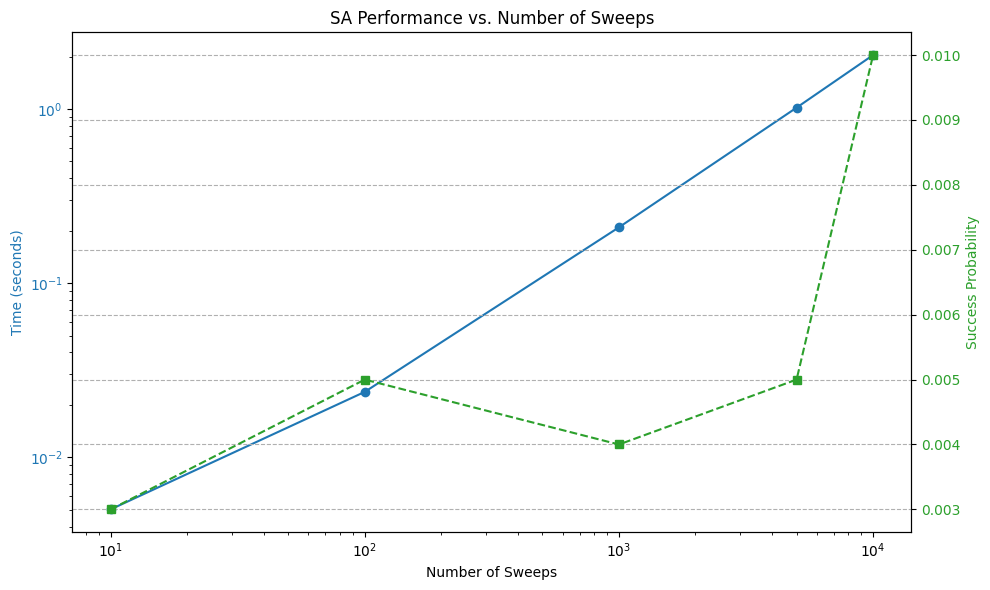

In [ ]:
# Plot the results of the sweep experiment
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Time on the primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Sweeps')
ax1.set_ylabel('Time (seconds)', color=color)
times = [sa_sweep_results[s]['time'] for s in num_sweeps_values]
ax1.plot(num_sweeps_values, times, 'o-', color=color, label='Time')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Create a secondary y-axis for Success Probability
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Success Probability', color=color)
probs = [sa_sweep_results[s]['success_prob'] for s in num_sweeps_values]
ax2.plot(num_sweeps_values, probs, 's--', color=color, label='Success Probability')
ax2.tick_params(axis='y', labelcolor=color)
# ax2.set_yscale('log') # Optional: use log scale if probabilities vary widely

# Final touches
plt.title('SA Performance vs. Number of Sweeps')
fig.tight_layout()
plt.grid(True, which="both", ls="--")
# plt.savefig('../report/figure/SA_Sweeps', dpi=300, bbox_inches='tight')
plt.show()

## Part 4: Comparison and Analysis

In [11]:
print("=" * 80)
print("PART 4: Comparison Table")
print("=" * 80)
print()

print(f"{'Method':<35} {'Value':<10} {'Weight':<10} {'Feasible':<12} {'Time (s)':<12}")
print("-" * 79)

print(f"{'Classical DP':<35} {classical_result['value']:<10} {classical_result['weight']:<10} {'Yes':<12} {classical_result['time']:<12.6f}")
print(f"{'Exact QUBO':<35} {exact_result['value']:<10} {exact_result['weight']:<10} {str(exact_result['feasible']):<12} {exact_result['time']:<12.6f}")

for num_reads in num_reads_values:
    r = sa_results[num_reads]
    yes_no = 'Yes' if r['feasible'] else 'No'
    name = f"SA (reads={num_reads})"
    print(f"{name:<35} {r['value']:<10} {r['weight']:<10} {yes_no:<12} {r['time']:<12.6f}")

print()

PART 4: Comparison Table

Method                              Value      Weight     Feasible     Time (s)    
-------------------------------------------------------------------------------
Classical DP                        309        165        Yes          0.001571    
Exact QUBO                          309        165        True         0.274831    
SA (reads=10)                       241        121        Yes          0.006463    
SA (reads=100)                      265        146        Yes          0.021812    
SA (reads=1000)                     309        165        Yes          0.210733    
SA (reads=10000)                    309        165        Yes          2.157283    

